# AlignPre / AlignPost — the keystone

**What you'll learn / who it's for (simulation *and* training).** This is the
central design of ``brainpy.state`` and the single most important page in this
documentation. You'll learn why a naive simulator drowns in synaptic state, how
**AlignPre** and **AlignPost** reduce that state from per-*synapse* to per-*neuron*
— *exactly*, not approximately — the four components every projection is built
from, and a decision table for choosing between the two. The chapter closes on the
reason this matters twice over: the same alignment that makes simulation
memory-efficient is what makes gradient-based and online learning memory-efficient.

A deep-learning reader can read "synapse" as "the recurrent hidden state of a
layer"; a neuroscience reader can read it literally. Both arrive at the same place.

## 1. The synaptic-state explosion

Give every synapse its own dynamical variable and the bookkeeping grows with the
number of *connections*. For a projection from $N_{\text{pre}}$ to
$N_{\text{post}}$ neurons at connection density $p$, naive per-synapse state costs

$$\mathcal{O}\!\left(p \cdot N_{\text{pre}} \cdot N_{\text{post}}\right).$$

Make it concrete. A modest cortical column might wire $10^4$ neurons to $10^4$
neurons at $10\%$ density. That is $\approx 10^7$ real synapses — but a naive
implementation that materializes a variable for *every* possible pre–post pair
allocates on the order of $10^8$ floats, and updates all of them every step.
Most of that is wasted: synapses that share dynamics are tracked redundantly.

The fix is not to approximate the dynamics. It is to notice that the redundancy is
*exact*, and to store one variable where many identical ones used to live.

## 2. The key observation

> *All synaptic variables sharing the same linear dynamics can be reduced to a
> single one.*

If a group of synapses obey the same differential equation and are driven by the
same input, their states are identical for all time — so one state suffices for the
whole group. The only question is **which dimension** the surviving variable should
live on. Align it to the **presynaptic** neurons and you get **AlignPre**; align it
to the **postsynaptic** neurons and you get **AlignPost**. Each is exact under a
clearly stated condition, and each is natural for a different connectivity shape.

## 3. Decoupling dynamics from communication — the four roles

``brainpy.state`` does not write projections as monolithic connection objects.
Every projection is composed from four interchangeable roles, and the *order* of
two of them is what distinguishes the two alignments:

- **``comm``** — *communication*. The connectivity itself: a sparse or dense weight
  matrix, or, equivalently, a deep-learning layer (``EventFixedProb``, ``Linear``,
  ``AllToAllProj``, …). It maps a presynaptic signal to a postsynaptic one.
- **``syn``** — *synapse dynamics*. The temporal filter applied to spikes
  (``Expon``, ``DualExpon``, ``AMPA``, ``GABAa``, ``BioNMDA``, …).
- **``out``** — *output*. How conductance becomes current: ``COBA`` (conductance-
  based, with reversal potential ``E``), ``CUBA`` (current-based), or ``MgBlock``
  (NMDA's voltage-dependent magnesium block).
- **``post``** — the postsynaptic ``Dynamics`` population that receives the current.

Because the roles are decoupled, you swap connectivity, kinetics, and biophysics
independently — and you place ``syn`` either **before** ``comm`` (AlignPre) or
**after** it (AlignPost). That single placement choice is the whole idea, and the
diagram below is the picture to hold in your head for the rest of the page.

```{eval-rst}
.. figure:: /_static/alignpre-alignpost.png
   :alt: Two panels. Left, "AlignPre": presynaptic neurons (orange) feed a
         synapse-dynamics box, then the green connection matrix, then the
         postsynaptic neurons (blue) -- synapse state lives BEFORE the matrix,
         on the presynaptic side, O(N_pre). Right, "AlignPost": presynaptic
         neurons (orange) feed the green connection matrix FIRST, then a
         synapse-dynamics box on the postsynaptic side, then the postsynaptic
         neurons (blue) -- synapse state lives AFTER the matrix, O(N_post).
   :width: 95%

   **AlignPre vs AlignPost.** The synapse-dynamics block sits *before* the
   connection matrix on the left (state aligned to the presynaptic population,
   :math:`\mathcal{O}(N_\text{pre})`, works for all synapses, natural for
   one-to-many) and *after* it on the right (state aligned to the postsynaptic
   population, :math:`\mathcal{O}(N_\text{post})`, exponential-family synapses,
   natural for many-to-one). *(Orange = presynaptic, blue = postsynaptic,
   green = connection matrix.)*
```

## 4. AlignPost — state aligned to the postsynaptic neurons

Put the synapse dynamics **after** ``comm``. Now the surviving state lives on the
$N_{\text{post}}$ postsynaptic neurons: memory is $\mathcal{O}(N_{\text{post}})$,
*independent of how many presynaptic neurons or connections feed in*.

Why is this exact? Recall the exponential synapse from
{doc}`/concepts/model-anatomy`: each arriving spike updates the postsynaptic
conductance by $g \leftarrow g + 1$, **regardless of which presynaptic neuron
emitted it**. Spikes from many sources therefore *superpose* — their separate
contributions sum linearly into one merged postsynaptic conductance. Tracking that
single merged variable reproduces the full per-synapse dynamics with no
approximation. The price of the trick is its precondition: it works **only for
synapse models with exponential (linear) dynamics**.

AlignPost is the natural choice for **many-to-one** fan-in (the dominant pattern in
recurrent networks) and is **event-driven**: only neurons that actually spiked
contribute.

### Worked example: the COBA excitatory–inhibitory network

The canonical balanced E–I network (Vogels & Abbott, 2005; Brette et al., 2007)
wires 4000 neurons to themselves through two AlignPost projections — one excitatory
(``E = 0 mV``), one inhibitory (``E = -80 mV``). Both use an exponential synapse, so
AlignPost applies. Note ``syn`` and ``out`` are passed as **describers**
(``Expon.desc(...)``, ``COBA.desc(...)``): the projection instantiates one shared
postsynaptic synapse from the description.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt


class EINet(brainstate.nn.Module):
    def __init__(self):
        super().__init__()
        self.n_exc, self.n_inh = 3200, 800
        self.num = self.n_exc + self.n_inh
        # one postsynaptic population of 4000 LIF-with-refractory neurons
        self.N = brainpy.state.LIFRef(
            self.num,
            V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV,
            tau=20. * u.ms, tau_ref=5. * u.ms,
            V_initializer=braintools.init.Normal(-55., 2., unit=u.mV),
        )
        # excitatory AlignPost projection: state aligned to the 4000 post neurons
        self.E = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(self.n_exc, self.num,
                                              conn_num=0.02, conn_weight=0.6 * u.mS),
            syn=brainpy.state.Expon.desc(self.num, tau=5. * u.ms),
            out=brainpy.state.COBA.desc(E=0. * u.mV),
            post=self.N,
        )
        # inhibitory AlignPost projection: shares the same post population
        self.I = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(self.n_inh, self.num,
                                              conn_num=0.02, conn_weight=6.7 * u.mS),
            syn=brainpy.state.Expon.desc(self.num, tau=10. * u.ms),
            out=brainpy.state.COBA.desc(E=-80. * u.mV),
            post=self.N,
        )

    def update(self, t, inp):
        with brainstate.environ.context(t=t):
            spk = self.N.get_spike() != 0.
            self.E(spk[:self.n_exc])   # excitatory neurons' spikes
            self.I(spk[self.n_exc:])   # inhibitory neurons' spikes
            self.N(inp)                # integrate synaptic + external current
            return self.N.get_spike()

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


  0%|          | 0/10000 [00:00<?, ?it/s]

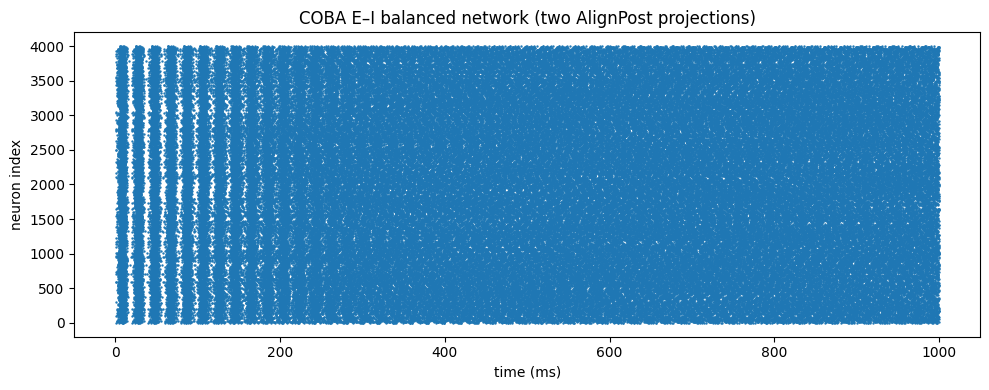

In [2]:
net = EINet()
brainstate.nn.init_all_states(net)

with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 1000. * u.ms, brainstate.environ.get_dt())
    spikes = brainstate.transform.for_loop(
        lambda t: net.update(t, 20. * u.mA), times,
        pbar=brainstate.transform.ProgressBar(10),
    )

# raster plot
t_idx, n_idx = u.math.where(spikes)
plt.figure(figsize=(10, 4))
plt.scatter(times[t_idx].to_decimal(u.ms), n_idx, s=0.5)
plt.xlabel('time (ms)'); plt.ylabel('neuron index')
plt.title('COBA E–I balanced network (two AlignPost projections)')
plt.tight_layout(); plt.show()

The synaptic state for each projection is a length-``num`` (4000) vector — one entry
per postsynaptic neuron — *no matter how many presynaptic spikes arrive each step*.
That is the $\mathcal{O}(N_{\text{post}})$ memory of AlignPost in practice.

## 5. AlignPre — state aligned to the presynaptic neurons

Put the synapse dynamics **before** ``comm``. Now the surviving state lives on the
$N_{\text{pre}}$ presynaptic neurons: memory is $\mathcal{O}(N_{\text{pre}})$.

Why exact here? With **homogeneous synaptic parameters per presynaptic neuron**,
every synapse leaving a given source neuron is driven by the *same* spike train
through the *same* dynamics — so they share one trace. Filter the spike train *once*
per presynaptic neuron, then let ``comm`` distribute the result. Because the
filtering happens before the (linear) connection matrix, the synapse model need
**not** be linear: AlignPre works for **all** synapse models, including the
voltage- and concentration-dependent ones — ``AMPA``, ``GABAa``, and ``BioNMDA``
(whose nonlinear kinetics rule out AlignPost).

AlignPre is the natural choice for **one-to-many** fan-out — one source population
broadcasting to several targets, where the single per-source trace is reused for
each.

### The canonical AlignPre API

AlignPre is exposed as the **function** ``brainpy.state.align_pre_projection`` —
there is intentionally no ``AlignPreProj`` class (AlignPost has both a class,
``AlignPostProj``, and a function, ``align_post_projection``). The function takes a
spike generator, then the same four roles, with ``syn`` placed *first* in the
pipeline so it filters in presynaptic space:

In [3]:
# A one-to-many fan-out with a nonlinear AMPA synapse -- AlignPost could not do this,
# because AMPA's kinetics are not a single linear exponential.
#
# Pattern (the canonical AlignPre call):
#
#   proj = brainpy.state.align_pre_projection(
#       pre,                                   # spike generator (the source population)
#       syn=brainpy.state.AMPA(n_pre),         # synapse dynamics in PRE space
#       comm=brainstate.nn.Linear(n_pre, n_post,
#                                 w_init=braintools.init.KaimingNormal(unit=u.mS),
#                                 b_init=None),
#       out=brainpy.state.COBA(E=0. * u.mV),   # conductance -> current
#       post=post,                             # postsynaptic population
#   )
#
# Per update: pre spikes -> syn filters them (one trace per presynaptic neuron)
#             -> comm distributes -> out -> post.
print('align_pre_projection is a function:',
      callable(brainpy.state.align_pre_projection))

align_pre_projection is a function: True


### Seeing where the state lives

The defining property of AlignPre is that the synapse state is sized by the
**presynaptic** population, not the postsynaptic one. The clearest way to *show*
that is to assemble the pipeline from its lower-level pieces — a ``syn`` evolving in
presynaptic space followed by a ``CurrentProj`` (the ``comm → out → post`` half that
``align_pre_projection`` wraps for you). Watch the shapes: ``syn.g`` has one entry
per *presynaptic* neuron, while the postsynaptic voltage has one entry per *target*.

In [4]:
class FanOut(brainstate.nn.Module):
    def __init__(self, n_pre=400, n_post=100):
        super().__init__()
        self.pre = brainpy.state.LIF(
            n_pre, tau=20. * u.ms, V_rest=-60. * u.mV, V_th=-50. * u.mV,
            V_reset=-60. * u.mV,
            V_initializer=braintools.init.Normal(-55., 2., unit=u.mV))
        self.post = brainpy.state.LIF(
            n_post, tau=20. * u.ms, V_rest=-60. * u.mV, V_th=-50. * u.mV,
            V_reset=-60. * u.mV)
        # synapse in PRE space: its state vector is length n_pre
        self.syn = brainpy.state.Expon(
            n_pre, tau=5. * u.ms, g_initializer=braintools.init.Constant(0.))
        # comm -> out -> post (what align_pre_projection wraps internally)
        self.proj = brainpy.state.CurrentProj(
            comm=brainstate.nn.Linear(n_pre, n_post,
                                      w_init=braintools.init.KaimingNormal(unit=u.mS),
                                      b_init=None),
            out=brainpy.state.COBA(E=0. * u.mV),
            post=self.post,
        )

    def update(self, t, inp):
        with brainstate.environ.context(t=t):
            g_pre = self.syn(self.pre.get_spike())  # filter in PRE space
            self.proj(g_pre)                         # distribute to POST
            self.pre(inp)
            self.post(0. * u.mA)
            return self.post.get_spike()


net = FanOut()
brainstate.nn.init_all_states(net)
print('syn.g lives on PRE neurons  ->', net.syn.g.value.shape, '(== n_pre = 400)')
print('post.V lives on POST neurons ->', net.post.V.value.shape, '(== n_post = 100)')

with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 100. * u.ms, brainstate.environ.get_dt())
    spk = brainstate.transform.for_loop(lambda t: net.update(t, 30. * u.mA), times)
print('post spike raster shape:', spk.shape)

syn.g lives on PRE neurons  -> (400,) (== n_pre = 400)
post.V lives on POST neurons -> (100,) (== n_post = 100)


post spike raster shape: (1000, 100)


The synapse vector is length 400 (the presynaptic count); the postsynaptic state is
length 100. Broadcast that one source population to a second or third target and the
*same* 400-entry trace is reused — that is the $\mathcal{O}(N_{\text{pre}})$ payoff
of AlignPre for one-to-many fan-out.

## 6. Exact, not approximate

It bears repeating, because it is the property that makes the whole design
trustworthy rather than a heuristic:

> *These projections are not approximations. They accurately compute the same
> dynamics as the original projections while providing new benefits.*
> — Wang et al., ICLR 2024.

Each alignment is exact **under its stated condition**:

- **AlignPre** requires **homogeneous synaptic parameters per presynaptic neuron**,
  so that all synapses from one source share a single trace. As the paper puts it:
  *"with homogeneous synaptic parameters, the spike train coming from the same
  presynaptic neuron will lead to the same synaptic dynamics … all synapses
  originating from the same presynaptic neuron can share a single dynamical
  variable … AlignPre … is suitable for all types of synapse models."*
- **AlignPost** requires **linear (exponential) synaptic dynamics**, so that
  contributions superpose. Again from the paper: *"the applicability of AlignPost is
  limited to synapse models that exhibit exponential dynamics … the conductance g of
  a post-synaptic neuron is updated according to* $g \leftarrow g + 1$ *whenever a
  spike arrives and regardless of which presynaptic neuron emitted this spike."*

When its condition holds, the reduction changes the memory footprint and nothing
else.

## 7. Automatic merging

Because synaptic state is keyed by a *neuron* dimension (plus the synapse/output
description), projections that target the same place with the same kinetics can
**share a single synapse instance** automatically:

- **AlignPost** — multiple projections into the same ``post`` population with the
  same ``syn``/``out`` descriptor share one postsynaptic synapse; their inputs sum
  into the merged conductance.
- **AlignPre** — projections from the same ``pre`` population (with the same delay)
  share one presynaptic synapse.

This is the additive-input convention from {doc}`/concepts/model-anatomy` paying
off: convergent pathways merge with no extra memory, and you express them simply by
pointing several projections at the same population.

## 8. Choosing between them

Reach for **AlignPost** when synapses are exponential-family and the wiring fans
*in* (many sources, one target) — the common recurrent-network case. Reach for
**AlignPre** when the synapse is nonlinear, or when one source fans *out* to many
targets. Both are exact; the choice is about which dimension is smaller and which
condition your synapse satisfies.

```{eval-rst}
.. list-table:: When to use AlignPre vs AlignPost
   :header-rows: 1
   :widths: 22 22 18 22 16

   * - Want
     - Synapse type
     - Connectivity
     - Use
     - State
   * - Event-driven fan-in
     - exponential-family (``Expon``, ``DualExpon``)
     - many → one
     - **AlignPost** (``AlignPostProj`` / ``align_post_projection``)
     - :math:`\mathcal{O}(N_\text{post})`
   * - Nonlinear kinetics
     - ``AMPA``, ``BioNMDA``, ``GABAa``
     - any
     - **AlignPre** (``align_pre_projection``)
     - :math:`\mathcal{O}(N_\text{pre})`
   * - One source → many targets
     - any
     - one → many
     - **AlignPre** (``align_pre_projection``)
     - :math:`\mathcal{O}(N_\text{pre})`
   * - Direct current / no synapse dynamics
     - —
     - any
     - ``CurrentProj`` / ``DeltaProj``
     - —
```

```{eval-rst}
.. list-table:: The three memory regimes
   :header-rows: 1
   :widths: 24 22 26 18 18

   * - Scheme
     - State lives on
     - State memory
     - Applies to
     - Best for
   * - Naïve per-synapse
     - each synapse
     - :math:`\mathcal{O}(p \cdot N_\text{pre} \cdot N_\text{post})`
     - any
     - *(wasteful)*
   * - **AlignPre**
     - presynaptic neurons
     - :math:`\mathcal{O}(N_\text{pre})`
     - **all** synapse models
     - one-to-many
   * - **AlignPost**
     - postsynaptic neurons
     - :math:`\mathcal{O}(N_\text{post})`
     - exponential-family only
     - many-to-one
```

```{eval-rst}
.. figure:: /_static/memory-complexity.png
   :alt: Three panels comparing memory. Panel 1 "Naive per-synapse": a dense full
         grid of connections between an orange presynaptic column and a blue
         postsynaptic column, labelled O(p * N_pre * N_post), marked wasteful.
         Panel 2 "AlignPre": each orange presynaptic neuron carries one trace that
         fans out to many blue postsynaptic neurons, labelled O(N_pre),
         one-to-many. Panel 3 "AlignPost": many orange presynaptic arrows converge
         into one merged trace on each blue postsynaptic neuron, labelled
         O(N_post), many-to-one, event-driven.
   :width: 95%

   **Three memory regimes.** Naive per-synapse state scales with the number of
   connections; AlignPre collapses it onto the presynaptic neurons
   (:math:`\mathcal{O}(N_\text{pre})`) and AlignPost onto the postsynaptic neurons
   (:math:`\mathcal{O}(N_\text{post})`) — both exactly.
```

## 9. The bridge to learning

Here is why this chapter is the keystone of the whole framework, not just a memory
optimization.

Aligning synaptic state to a **neuron** dimension instead of a **weight** dimension
does more than shrink the forward pass. It is *also* what makes gradient-based and
online learning tractable. Backpropagation-through-time differentiates the very
``for_loop`` you used above, and neuron-aligned state keeps the activations it must
remember small (see {doc}`/concepts/differentiability`). More dramatically, in
**real-time recurrent learning (RTRL)** the same superposition that makes AlignPost's
*forward* pass exact is reused on the *backward* pass: the eligibility traces and
Jacobians that would otherwise scale cubically/quadratically with the number of
hidden units collapse to **linear** memory. That is the result of Wang et al. (2026,
*Nature Communications*), and it is what puts whole-brain-scale online learning
within reach.

In one sentence: **the alignment that makes simulation memory-efficient is the
alignment that makes learning memory-efficient.** The two worlds — brain simulation
and brain-inspired computing — meet exactly here.

Continue to {doc}`/concepts/online-learning` for the linear-memory story.

## 10. API pointers

- **AlignPost** — class ``brainpy.state.AlignPostProj`` and function
  ``brainpy.state.align_post_projection`` (``syn``/``out`` as ``.desc(...)``
  describers).
- **AlignPre** — function ``brainpy.state.align_pre_projection`` (no class).
- **Direct injection** — ``brainpy.state.CurrentProj`` (continuous current, no
  synapse) and ``brainpy.state.DeltaProj`` (instantaneous delta input).
- **Gap junctions** — ``brainpy.state.SymmetryGapJunction`` /
  ``brainpy.state.AsymmetryGapJunction`` for electrical coupling.
- **Short-term plasticity** — pass ``stp=brainpy.state.STP(...)`` (or ``STD``) to
  ``align_pre_projection`` / ``align_post_projection``.

See {doc}`/apis/index` for full signatures.

## References

- Wang, C., Zhang, T., He, S., Gu, H., Li, S., Wu, S. (2024). *A differentiable
  brain simulator bridging brain simulation and brain-inspired computing.* ICLR
  2024. <https://openreview.net/forum?id=AU2gS9ut61> (arXiv:2311.05106). —
  introduces AlignPre / AlignPost.
- Vogels, T. P. & Abbott, L. F. (2005). *Signal propagation and logic gating in
  networks of integrate-and-fire neurons.* J. Neurosci. 25(46), 10786–95. — the
  balanced E–I network reproduced above.

## See also

- {doc}`/concepts/model-anatomy` — the ``comm`` / ``syn`` / ``out`` / ``post``
  pieces and the ``g ← g + 1`` increment this design exploits.
- {doc}`/concepts/differentiability` — backpropagation-through-time over the same
  models.
- {doc}`/concepts/online-learning` — linear-memory RTRL, the learning-side payoff.
- {doc}`/brainpy-style/index` — projections applied in tutorials and how-to guides.